In [1]:
!pip install sentence-transformers==2.2.2
!pip install wordfreq
from tqdm import tqdm
import nltk
import pandas as pd 
import numpy as np
import gc
import json
from nltk.corpus import stopwords
from collections import Counter
from itertools import chain
from sentence_transformers import SentenceTransformer, models, util
import re
import torch
from scipy.stats import zscore  # For calculating z-scores
from wordfreq import top_n_list
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from tqdm import tqdm
import csv
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ done
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125924 sha256=c5aa70d8b56dc423656b70ab2cd4aad5d06b2a08397be5b61cb2b4319b60be3f
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [2]:
# Define a function to perform bootstrapping and calculate confidence intervals
def bootstrap_ci(data, num_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(num_bootstrap):
        sample = data.sample(frac=1, replace=True)
        boot_means.append(sample.mean())
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound

    
def get_embeddings(text, model):
    text = [str(t) for t in text]
    #encode text in batches 
    corpus_embeddings = model.encode(text, batch_size=1024, show_progress_bar=False, convert_to_tensor=True)
    assert len(corpus_embeddings) == len(text)
    return corpus_embeddings

def get_z_scores(model, lexicon, df):
    
    def process_batch(batch_df):
        # Process each batch
        top_words_list = batch_df["word"].tolist()
        top_words_embeddings = get_embeddings(top_words_list, model)

        evidence_sim_batch = util.cos_sim(top_words_embeddings, evidence_embeddings)
        intuition_sim_batch = util.cos_sim(top_words_embeddings, intuition_embeddings)

        batch_df['evidence_score'] = evidence_sim_batch.cpu().numpy()
        batch_df['intuition_score'] = intuition_sim_batch.cpu().numpy()
        return batch_df

    # Load lexicon and get embeddings
    evidence_keywords = pd.read_csv(lexicon)['evidence'].dropna().tolist()
    intuition_keywords = pd.read_csv(lexicon)['intuition'].dropna().tolist()

    # Get mean embeddings for lexicon categories
    evidence_embeddings = torch.mean(get_embeddings(evidence_keywords, model), dim=0).to(device)
    intuition_embeddings = torch.mean(get_embeddings(intuition_keywords, model), dim=0).to(device)

    # Process in batches if df is larger than 1500 rows
    batch_size = 100_000
    if len(df) > batch_size:
        result_df = pd.concat([process_batch(df[i:i + batch_size]) for i in tqdm(range(0, len(df), batch_size))], ignore_index=True)
    else:
        result_df = process_batch(df)

    # Apply z-score normalization
    result_df[['evidence_z', 'intuition_z']] = result_df[['evidence_score', 'intuition_score']].apply(zscore)
    
    return result_df
    

In [3]:
df_twitter = pd.read_csv("/kaggle/input/final-data/twitter.csv")
# Apply the function to get z-scores for the most common words
lexicon_path = "/kaggle/input/dictionary2/PRODEMINFO_German_keywords.csv"  # Replace with the actual path to your lexicon CSV
model_path = "/kaggle/input/sbert-twitter/twitter_model"     # Replace with the actual path or model name

# Correlation of length and similarities 

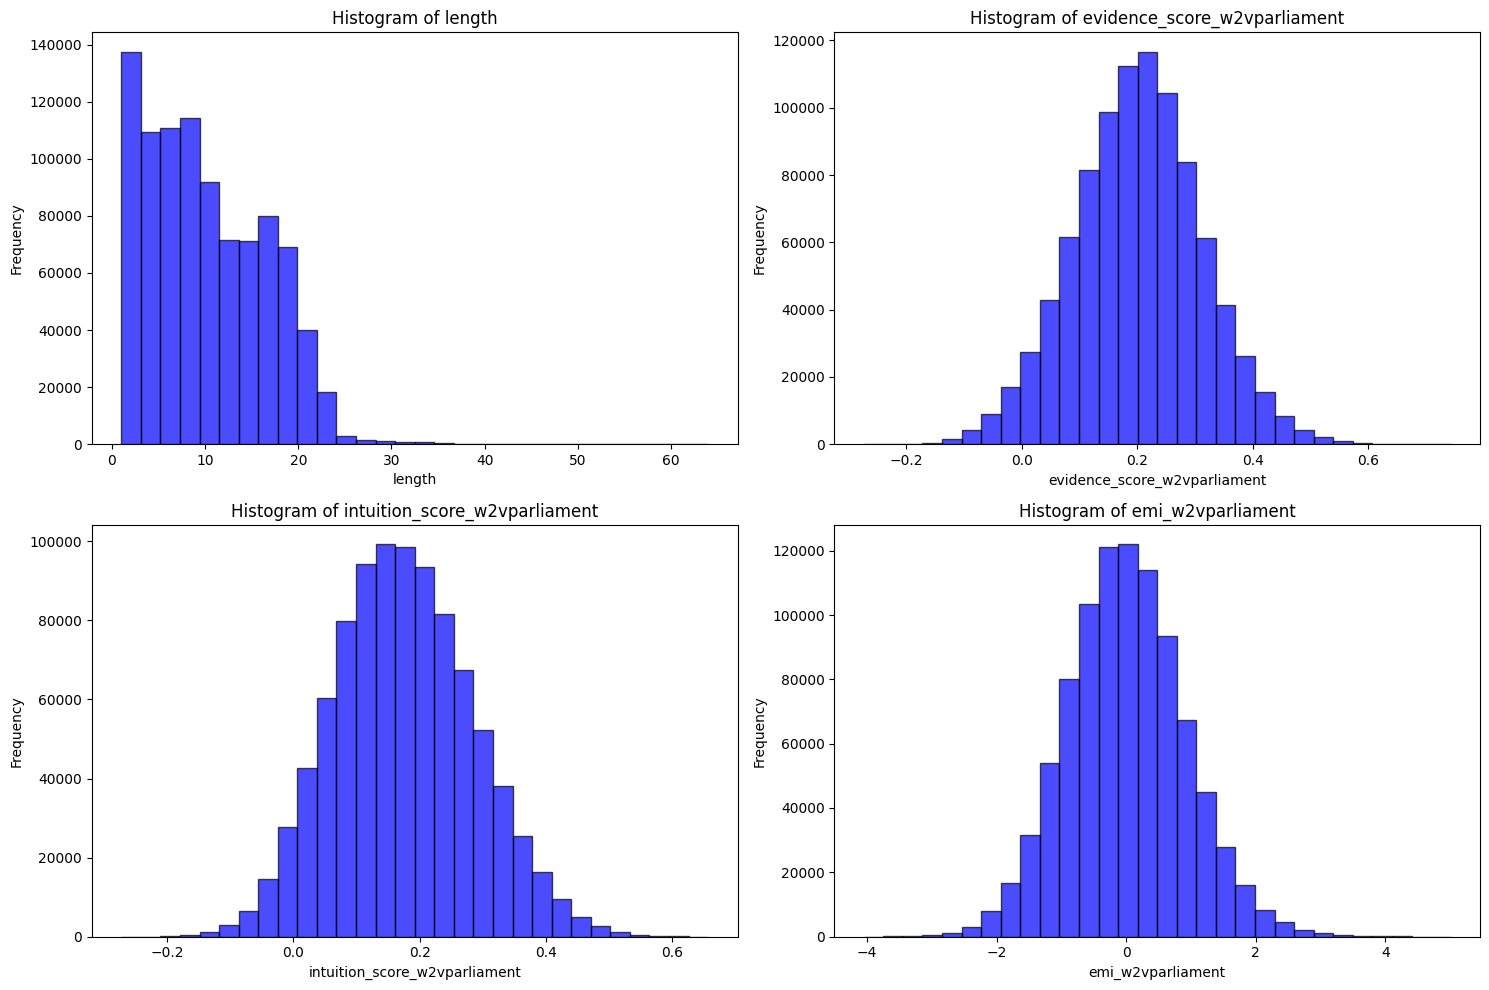

In [4]:
# Create histograms for the selected columns
columns_to_plot = ['length', 'evidence_score_w2vparliament', 'intuition_score_w2vparliament', 'emi_w2vparliament']

# Set the figure size for better visualization
plt.figure(figsize=(15, 10))

# Loop through each column and create a subplot
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(2, 2, i)
    plt.hist(df_twitter[column], bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Scatterplot 

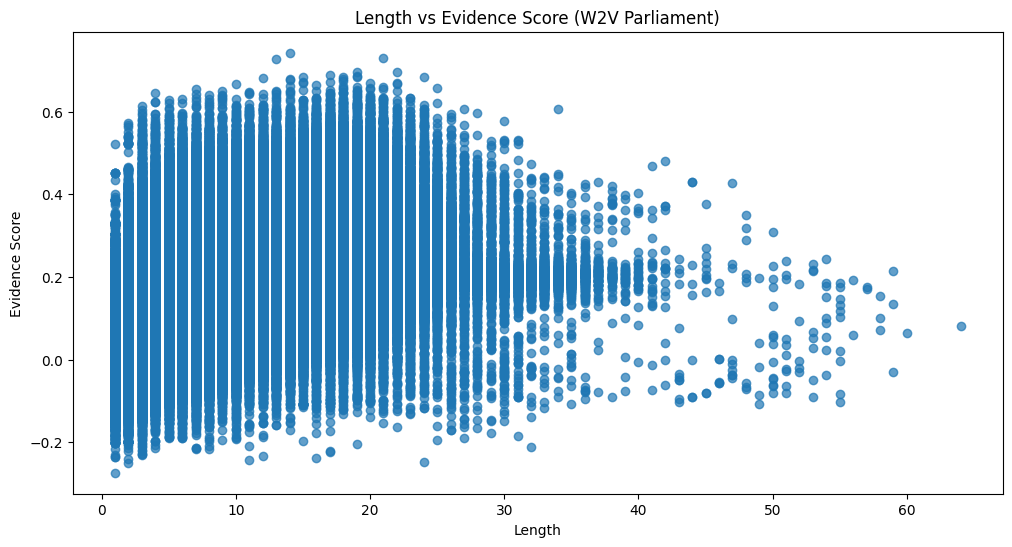

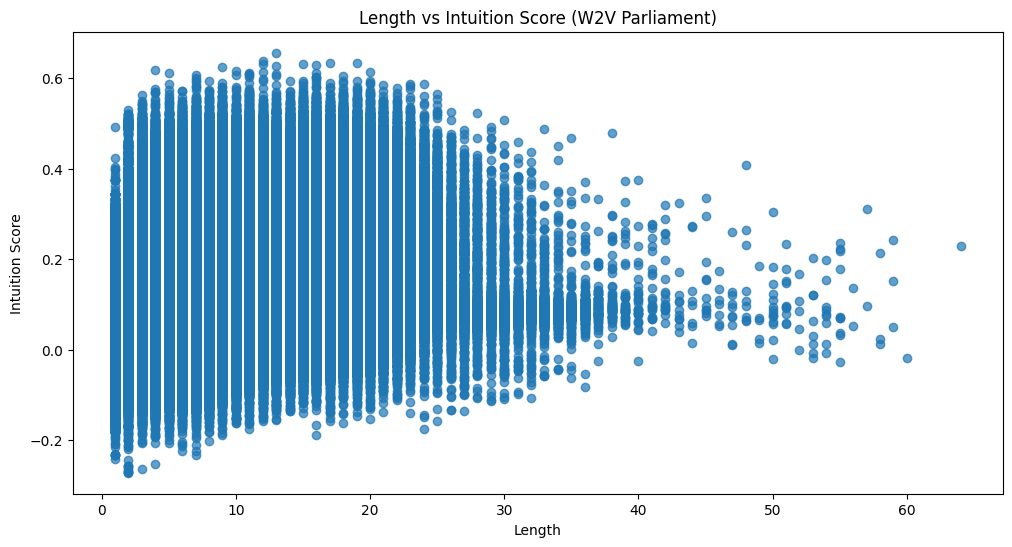

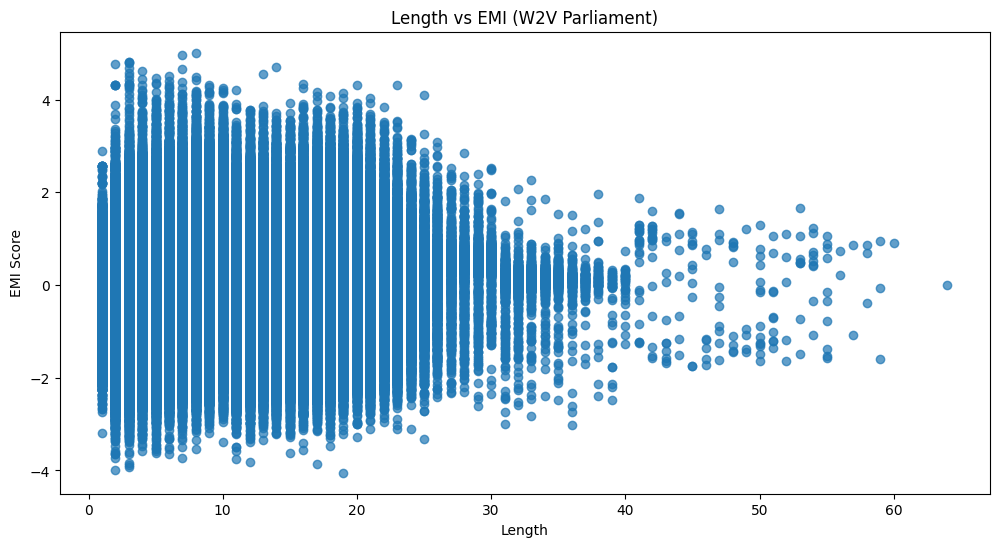

In [5]:
# Create scatter plots
plt.figure(figsize=(12, 6))
plt.scatter(df_twitter['length'], df_twitter['evidence_score_w2vparliament'], alpha=0.7)
plt.title("Length vs Evidence Score (W2V Parliament)")
plt.xlabel("Length")
plt.ylabel("Evidence Score")
plt.savefig("scatter_length_emi.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(df_twitter['length'], df_twitter['intuition_score_w2vparliament'], alpha=0.7)
plt.title("Length vs Intuition Score (W2V Parliament)")
plt.xlabel("Length")
plt.ylabel("Intuition Score")
plt.savefig("scatter_length_inutition.png")
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(df_twitter['length'], df_twitter['emi_w2vparliament'], alpha=0.7)
plt.title("Length vs EMI (W2V Parliament)")
plt.xlabel("Length")
plt.ylabel("EMI Score")
plt.savefig("scatter_length_evidence.png")
plt.show()

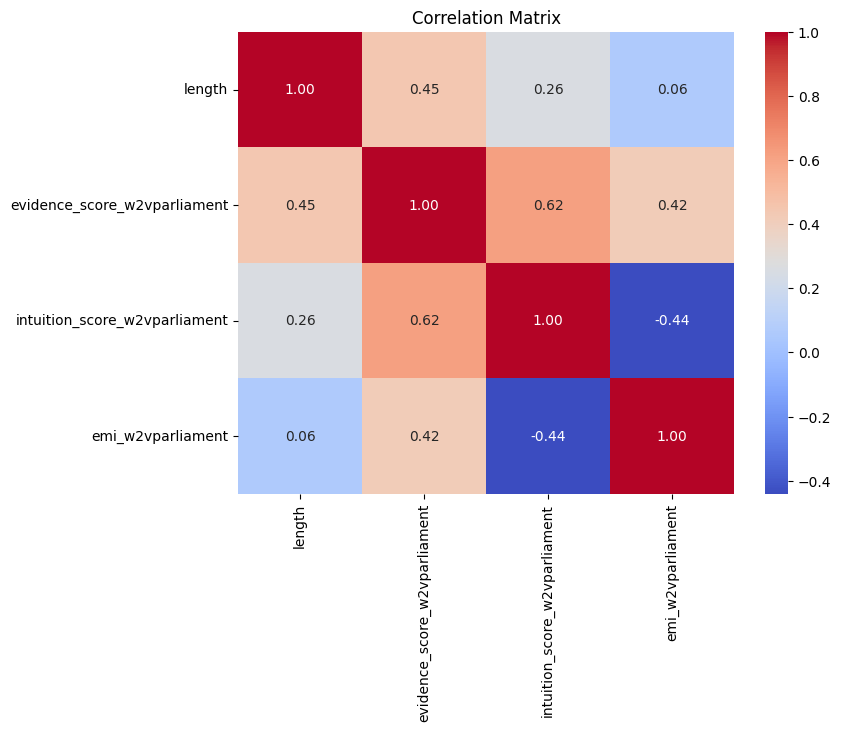

In [6]:
# Compute correlation matrix
correlation_matrix = df_twitter[['length', 'evidence_score_w2vparliament', 'intuition_score_w2vparliament', 'emi_w2vparliament']].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("correlation_length_similarities.png")
plt.show()

In [7]:
model = SentenceTransformer("/kaggle/input/sbert-twitter/twitter_model")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/opt/conda/lib/python3.10/site-packages/sentence_transformers/models/WordEmbeddings.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(os.path.join(in

SentenceTransformer(
  (0): WordEmbeddings(
    (emb_layer): Embedding(2865585, 300)
  )
  (1): Pooling({'word_embedding_dimension': 300, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False})
)

In [8]:
# Extract all words and convert to lowercase
all_words = []
df_twitter['text_clean'].apply(lambda x: all_words.extend(str(x).split()))

# Count the frequency of each unique word
word_freq = Counter(all_words)

# Create a DataFrame from the frequency dictionary
all_words_df = pd.DataFrame(word_freq.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)
all_words_df

,word,frequency
83,amp,59528
886,AfD,28430
20,Menschen,27707
666,CDU,26387
182,Bundestag,24981
...,...,...
539331,Konträre,1
539332,httpstcopVLETFJ,1
539333,haraldhamann,1
539336,httpstcosDIlPfEbm,1


In [9]:
all_words_df = get_z_scores(model, "/kaggle/input/dictionary2/PRODEMINFO_German_keywords.csv", all_words_df)

  0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_17/1889428421.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  batch_df['evidence_score'] = evidence_sim_batch.cpu().numpy()
/tmp/ipykernel_17/1889428421.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  batch_df['intuition_score'] = intuition_sim_batch.cpu().numpy()
  8%|▊         | 1/13 [00:02<00:25,  2.11s/it]/tmp/ipykernel_17/1889428421.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [10]:
all_words_df

,word,frequency,evidence_score,intuition_score,evidence_z,intuition_z
0,amp,59528,0.016625,-0.051803,-0.437982,-1.274571
1,AfD,28430,0.100231,0.175631,0.669512,1.558430
2,Menschen,27707,0.119558,0.094170,0.925539,0.543726
3,CDU,26387,0.084597,0.147458,0.462424,1.207500
4,Bundestag,24981,0.038477,0.034656,-0.148515,-0.197605
...,...,...,...,...,...,...
1259155,Konträre,1,-0.026777,-0.042812,-1.012913,-1.162579
1259156,httpstcopVLETFJ,1,-0.045653,-0.049021,-1.262959,-1.239920
1259157,haraldhamann,1,0.084443,0.101265,0.460382,0.632096
1259158,httpstcosDIlPfEbm,1,0.011459,0.056334,-0.506416,0.072418


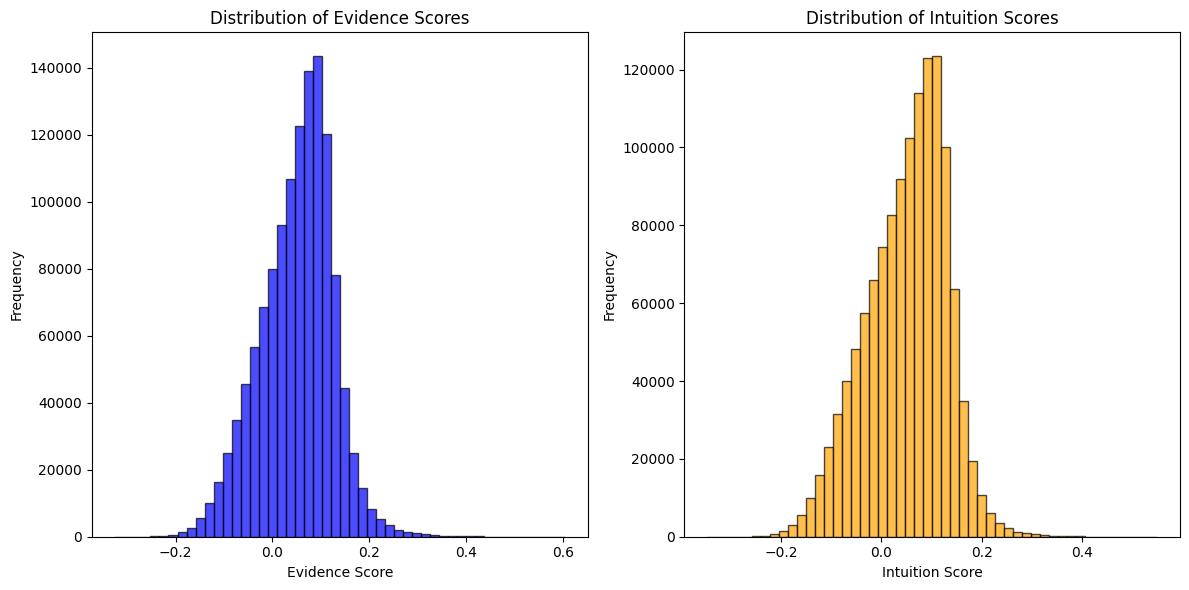

In [11]:
# Assume `result_df` contains the columns `evidence_score`, `intuition_score`, and `words`
# Generate histograms for evidence_score and intuition_score
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(all_words_df['evidence_score'], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title("Distribution of Evidence Scores")
plt.xlabel("Evidence Score")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(all_words_df['intuition_score'], bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.title("Distribution of Intuition Scores")
plt.xlabel("Intuition Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("similarity_distribution_all_word.png")
plt.show()

In [12]:
all_words_df.to_csv("tweets_corpus.csv", index = False)